# 01 Variable Selection and Harmonization

This notebook covers the selection of demographic, digital, and accessibility indicators and their harmonization for clustering.

In [2]:
import pandas as pd
from scipy import stats
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns


In [36]:
total_file = r'../data/Total.csv'

# Load the CSV files into pandas DataFrames

total_df = pd.read_csv(total_file)


In [5]:
total_df.columns


Index(['LSOA21CD', 'Aged 4 years and under', 'Aged 5 to 9 years',
       'Aged 10 to 15 years', 'Aged 16 to 19 years', 'Aged 20 to 24 years',
       'Aged 25 to 34 years', 'Aged 35 to 49 years', 'Aged 50 to 64 years',
       'Aged 65 to 74 years', 'Aged 75 to 84 years', 'Aged 85 years and over',
       'Never married and never registered a civil partnership',
       'Married or in a registered civil partnership',
       'Separated, but still legally married or still legally in a civil partnership',
       'Divorced or civil partnership dissolved',
       'Widowed or surviving civil partnership partner',
       'No cars or vans in household', '1 car or van in household',
       '2 cars or vans in household', '3 or more cars or vans in household',
       'Household is not deprived in any dimension',
       'Household is deprived in one dimension',
       'Household is deprived in two dimensions',
       'Household is deprived in three dimensions',
       'Household is deprived in four di

In [40]:
import pandas as pd

# Assuming total_df is your DataFrame

# Combine age groups
total_df['%Children and Teenagers (0-19 years)'] = total_df[
    ['Aged 4 years and under', 'Aged 5 to 9 years', 'Aged 10 to 15 years', 'Aged 16 to 19 years']
].sum(axis=1)

total_df['%Young Adults (20-34 years)'] = total_df[
    ['Aged 20 to 24 years', 'Aged 25 to 34 years']
].sum(axis=1)

total_df['%Middle-Aged Adults (35-49 years)'] = total_df['Aged 35 to 49 years']

total_df['%Older Adults (50-64 years)'] = total_df['Aged 50 to 64 years']

total_df['%Elderly (65+ years)'] = total_df[
    ['Aged 65 to 74 years', 'Aged 75 to 84 years', 'Aged 85 years and over']
].sum(axis=1)

# Combine marital status
total_df['%Currently Married/Partnered'] = total_df['Married or in a registered civil partnership']
total_df['%Previously Married'] = total_df[
    ['Separated, but still legally married or still legally in a civil partnership', 
     'Divorced or civil partnership dissolved', 
     'Widowed or surviving civil partnership partner']
].sum(axis=1)
total_df['%Never Married'] = total_df['Never married and never registered a civil partnership']

# Combine car ownership
total_df['%No Car/Van'] = total_df['No cars or vans in household']
total_df['%One Car/Van'] = total_df['1 car or van in household']
total_df['%Multiple Cars/Vans'] = total_df[['2 cars or vans in household', '3 or more cars or vans in household']].sum(axis=1)

# Combine household deprivation
total_df['%No Deprivation'] = total_df['Household is not deprived in any dimension']
total_df['%Low Deprivation'] = total_df['Household is deprived in one dimension']
total_df['%Medium Deprivation'] = total_df[['Household is deprived in two dimensions', 'Household is deprived in three dimensions']].sum(axis=1)
total_df['%High Deprivation'] = total_df['Household is deprived in four dimensions']

# Combine distance to work
total_df['%Short Distance to Work'] = total_df[['Less than 2km', '2km to less than 5km']].sum(axis=1)
total_df['%Medium Distance to Work'] = total_df[['5km to less than 10km', '10km to less than 20km']].sum(axis=1)
total_df['%Long Distance to Work'] = total_df[['20km to less than 30km', '30km to less than 40km', '40km to less than 60km', '60km and over']].sum(axis=1)

# Combine workplace type
total_df['%Fixed Workplace'] = total_df[['Works mainly from home', 'Works mainly at an offshore installation, in no fixed place, or outside the UK']].sum(axis=1)
total_df['%Economically Active'] = total_df[['Economically active (excluding full-time students)', 'Economically active and a full-time student']].sum(axis=1)
total_df['%Economically Inactive'] = total_df[['Economically inactive']].sum(axis=1)

# Combine health status
total_df['%Good Health'] = total_df[['Very good health', 'Good health']].sum(axis=1)
total_df['%Fair Health'] = total_df['Fair health']
total_df['%Poor Health'] = total_df[['Bad health', 'Very bad health']].sum(axis=1)

# Combine education level
total_df['%Low Education'] = total_df[['No qualifications', 'Level 1 and entry level qualifications']].sum(axis=1)
total_df['%Medium Education'] = total_df[['Level 2 qualifications', 'Apprenticeship', 'Level 3 qualifications']].sum(axis=1)
total_df['%High Education'] = total_df[['Level 4 qualifications or above', 'Other qualifications']].sum(axis=1)

# Combine occupation types
total_df['%High Managerial/Professional'] = total_df['L1, L2 and L3 Higher managerial, administrative and professional occupations']
total_df['%Lower Managerial/Technical'] = total_df[['L4, L5 and L6 Lower managerial, administrative and professional occupations', 'L10 and L11 Lower supervisory and technical occupations']].sum(axis=1)
total_df['%Routine/Unskilled Jobs'] = total_df[['L12 Semi-routine occupations', 'L13 Routine occupations', 'L14.1 and L14.2 Never worked and long-term unemployed']].sum(axis=1)
total_df['%Self-employed/Small Business'] = total_df['L8 and L9 Small employers and own account workers']
total_df['%Full-time Students'] = total_df['L15 Full-time students']

# Combine housing tenure
total_df['%Owned'] = total_df[['Owned', 'Owns with a mortgage or loan or shared ownership']].sum(axis=1)
total_df['%Social Rented'] = total_df[['Social rented', 'Private rented or lives rent free']].sum(axis=1)

# Combine household size
total_df['%Small Household (1-2 people)'] = total_df[['1 person in household', '2 people in household']].sum(axis=1)
total_df['%Medium Household (3-4 people)'] = total_df[['3 people in household', '4 people in household']].sum(axis=1)
total_df['%Large Household (5+ people)'] = total_df[['5 people in household', '6 people in household', '7 people in household', '8 or more people in household']].sum(axis=1)

# Combine gender
total_df['%Female'] = total_df['Female']
total_df['%Male'] = total_df['Male']

# Handle special ownership types
total_df['%Shared Ownership'] = total_df['Shared ownership']
total_df['%Private Rented'] = total_df['Private rented']
total_df['%Lives Rent Free'] = total_df['Lives rent free']

# Combine zero-person households (if relevant)
total_df['%Zero Person Households'] = total_df['0 people in household']

# Drop original columns after combining if you don't need them anymore
total_df.drop(columns=[
    'Aged 4 years and under', 'Aged 5 to 9 years', 'Aged 10 to 15 years', 'Aged 16 to 19 years', 'Aged 20 to 24 years', 'Aged 25 to 34 years', 
    'Aged 35 to 49 years', 'Aged 50 to 64 years', 'Aged 65 to 74 years', 'Aged 75 to 84 years', 'Aged 85 years and over',
    'Never married and never registered a civil partnership', 'Married or in a registered civil partnership',
    'Separated, but still legally married or still legally in a civil partnership', 'Divorced or civil partnership dissolved',
    'Widowed or surviving civil partnership partner', 'No cars or vans in household', '1 car or van in household', 
    '2 cars or vans in household', '3 or more cars or vans in household', 'Household is not deprived in any dimension', 
    'Household is deprived in one dimension', 'Household is deprived in two dimensions', 'Household is deprived in three dimensions', 
    'Household is deprived in four dimensions', 'Less than 2km', '2km to less than 5km', '5km to less than 10km', '10km to less than 20km', 
    '20km to less than 30km', '30km to less than 40km', '40km to less than 60km', '60km and over', 'Works mainly from home', 
    'Works mainly at an offshore installation, in no fixed place, or outside the UK', 'Economically active (excluding full-time students)', 
    'Economically active and a full-time student', 'Economically inactive', 'Very good health', 
    'Good health', 'Fair health', 'Bad health', 'Very bad health', 'No qualifications', 'Level 1 and entry level qualifications', 
    'Level 2 qualifications', 'Apprenticeship', 'Level 3 qualifications', 'Level 4 qualifications or above', 'Other qualifications', 
    'L1, L2 and L3 Higher managerial, administrative and professional occupations', 'L4, L5 and L6 Lower managerial, administrative and professional occupations',
    'L7 Intermediate occupations', 'L8 and L9 Small employers and own account workers', 'L10 and L11 Lower supervisory and technical occupations', 
    'L12 Semi-routine occupations', 'L13 Routine occupations', 'L14.1 and L14.2 Never worked and long-term unemployed', 'L15 Full-time students',
    'Owned', 'Owns with a mortgage or loan or shared ownership', 'Social rented', 'Private rented or lives rent free', '1 person in household', 
    '2 people in household', '3 people in household', '4 people in household', '5 people in household', '6 people in household', 
    '7 people in household', '8 or more people in household', 'Female', 'Male', 'Shared ownership', 'Private rented', 'Lives rent free', '0 people in household'
], inplace=True)

# Check the resulting DataFrame
print(total_df.head())


                      LSOA21CD  Economically inactive: Retired  \
0  E01011954 : Hartlepool 001A                            18.0   
1  E01011969 : Hartlepool 001B                            38.0   
2  E01011970 : Hartlepool 001C                            33.6   
3  E01011971 : Hartlepool 001D                            16.3   
4  E01033465 : Hartlepool 001F                            14.5   

   %Children and Teenagers (0-19 years)  %Young Adults (20-34 years)  \
0                                  27.5                         20.5   
1                                  17.7                         13.2   
2                                  15.0                         16.3   
3                                  23.5                         17.9   
4                                  29.3                         16.1   

   %Middle-Aged Adults (35-49 years)  %Older Adults (50-64 years)  \
0                               17.3                         20.6   
1                               

In [7]:
import pandas as pd

# Assuming total_df is your DataFrame

# Combine age groups
total_df['%Children and Teenagers (0-19 years)'] = total_df[
    ['Aged 4 years and under', 'Aged 5 to 9 years', 'Aged 10 to 15 years', 'Aged 16 to 19 years']
].sum(axis=1)

total_df['%Young Adults (20-34 years)'] = total_df[
    ['Aged 20 to 24 years', 'Aged 25 to 34 years']
].sum(axis=1)

total_df['%Middle-Aged Adults (35-49 years)'] = total_df[
    ['Aged 35 to 49 years']
]

total_df['%Older Adults (50-64 years)'] = total_df[
    ['Aged 50 to 64 years']
]

total_df['%Elderly (65+ years)'] = total_df[
    ['Aged 65 to 74 years', 'Aged 75 to 84 years', 'Aged 85 years and over']
].sum(axis=1)

# Combine marital status
total_df['%Currently Married/Partnered'] = total_df['Married or in a registered civil partnership']
total_df['%Previously Married'] = total_df[
    ['Separated, but still legally married or still legally in a civil partnership', 
     'Divorced or civil partnership dissolved', 
     'Widowed or surviving civil partnership partner']
].sum(axis=1)
total_df['%Never Married'] = total_df['Never married and never registered a civil partnership']

# Combine car ownership
total_df['%No Car/Van'] = total_df['No cars or vans in household']
total_df['%One Car/Van'] = total_df['1 car or van in household']
total_df['%Multiple Cars/Vans'] = total_df[['2 cars or vans in household', '3 or more cars or vans in household']].sum(axis=1)

# Combine household deprivation
total_df['%No Deprivation'] = total_df['Household is not deprived in any dimension']
total_df['%Low Deprivation'] = total_df['Household is deprived in one dimension']
total_df['%Medium Deprivation'] = total_df[['Household is deprived in two dimensions', 'Household is deprived in three dimensions']].sum(axis=1)
total_df['%High Deprivation'] = total_df['Household is deprived in four dimensions']

# Combine distance to work
total_df['%Short Distance to Work'] = total_df[['Less than 2km', '2km to less than 5km']].sum(axis=1)
total_df['%Medium Distance to Work'] = total_df[['5km to less than 10km', '10km to less than 20km']].sum(axis=1)
total_df['%Long Distance to Work'] = total_df[['20km to less than 30km', '30km to less than 40km', '40km to less than 60km', '60km and over']].sum(axis=1)

# Combine workplace type
total_df['%Fixed Workplace'] = total_df[['Works mainly from home', 'Works mainly at an offshore installation, in no fixed place, or outside the UK']].sum(axis=1)
total_df['%Economically Active'] = total_df[['Economically active (excluding full-time students)', 'Economically active and a full-time student']].sum(axis=1)
total_df['%Economically Inactive'] = total_df[['Economically inactive', 'Economically inactive: Retired']].sum(axis=1)

# Combine health status
total_df['%Good Health'] = total_df[['Very good health', 'Good health']].sum(axis=1)
total_df['%Fair Health'] = total_df['Fair health']
total_df['%Poor Health'] = total_df[['Bad health', 'Very bad health']].sum(axis=1)

# Combine education level
total_df['%Low Education'] = total_df[['No qualifications', 'Level 1 and entry level qualifications']].sum(axis=1)
total_df['%Medium Education'] = total_df[['Level 2 qualifications', 'Apprenticeship', 'Level 3 qualifications']].sum(axis=1)
total_df['%High Education'] = total_df[['Level 4 qualifications or above', 'Other qualifications']].sum(axis=1)

# Combine occupation types
total_df['%High Managerial/Professional'] = total_df['L1, L2 and L3 Higher managerial, administrative and professional occupations']
total_df['%Lower Managerial/Technical'] = total_df[['L4, L5 and L6 Lower managerial, administrative and professional occupations', 'L10 and L11 Lower supervisory and technical occupations']].sum(axis=1)
total_df['%Routine/Unskilled Jobs'] = total_df[['L12 Semi-routine occupations', 'L13 Routine occupations', 'L14.1 and L14.2 Never worked and long-term unemployed']].sum(axis=1)
total_df['%Self-employed/Small Business'] = total_df['L8 and L9 Small employers and own account workers']
total_df['%Full-time Students'] = total_df['L15 Full-time students']

# Combine housing tenure
total_df['%Owned'] = total_df[['Owned', 'Owns with a mortgage or loan or shared ownership']].sum(axis=1)
total_df['%Rented'] = total_df[['Social rented', 'Private rented or lives rent free']].sum(axis=1)

# Combine household size
total_df['%Small Household (1-2 people)'] = total_df[['1 person in household', '2 people in household']].sum(axis=1)
total_df['%Medium Household (3-4 people)'] = total_df[['3 people in household', '4 people in household']].sum(axis=1)
total_df['%Large Household (5+ people)'] = total_df[['5 people in household', '6 people in household', '7 people in household', '8 or more people in household']].sum(axis=1)

# Drop original columns after combining if you don't need them anymore
total_df.drop(columns=[
    'Aged 4 years and under', 'Aged 5 to 9 years', 'Aged 10 to 15 years', 'Aged 16 to 19 years', 'Aged 20 to 24 years', 'Aged 25 to 34 years', 
    'Aged 35 to 49 years', 'Aged 50 to 64 years', 'Aged 65 to 74 years', 'Aged 75 to 84 years', 'Aged 85 years and over',
    'Never married and never registered a civil partnership', 'Married or in a registered civil partnership',
    'Separated, but still legally married or still legally in a civil partnership', 'Divorced or civil partnership dissolved',
    'Widowed or surviving civil partnership partner', 'No cars or vans in household', '1 car or van in household', 
    '2 cars or vans in household', '3 or more cars or vans in household', 'Household is not deprived in any dimension', 
    'Household is deprived in one dimension', 'Household is deprived in two dimensions', 'Household is deprived in three dimensions', 
    'Household is deprived in four dimensions', 'Less than 2km', '2km to less than 5km', '5km to less than 10km', '10km to less than 20km', 
    '20km to less than 30km', '30km to less than 40km', '40km to less than 60km', '60km and over', 'Works mainly from home', 
    'Works mainly at an offshore installation, in no fixed place, or outside the UK', 'Economically active (excluding full-time students)', 
    'Economically active and a full-time student', 'Economically inactive', 'Economically inactive: Retired', 'Very good health', 
    'Good health', 'Fair health', 'Bad health', 'Very bad health', 'No qualifications', 'Level 1 and entry level qualifications', 
    'Level 2 qualifications', 'Apprenticeship', 'Level 3 qualifications', 'Level 4 qualifications or above', 'Other qualifications', 
    'L1, L2 and L3 Higher managerial, administrative and professional occupations', 'L4, L5 and L6 Lower managerial, administrative and professional occupations',
    'L7 Intermediate occupations', 'L8 and L9 Small employers and own account workers', 'L10 and L11 Lower supervisory and technical occupations', 
    'L12 Semi-routine occupations', 'L13 Routine occupations', 'L14.1 and L14.2 Never worked and long-term unemployed', 'L15 Full-time students',
    'Owned', 'Owns with a mortgage or loan or shared ownership', 'Social rented', 'Private rented or lives rent free', '1 person in household', 
    '2 people in household', '3 people in household', '4 people in household', '5 people in household', '6 people in household', 
    '7 people in household', '8 or more people in household'
], inplace=True)

# Check the resulting DataFrame
print(total_df.head())


                      LSOA21CD  Female  Male  Shared ownership  \
0  E01011954 : Hartlepool 001A    52.6  47.4               0.2   
1  E01011969 : Hartlepool 001B    50.6  49.4               0.0   
2  E01011970 : Hartlepool 001C    51.4  48.6               0.2   
3  E01011971 : Hartlepool 001D    51.9  48.1               0.8   
4  E01033465 : Hartlepool 001F    50.3  49.7               0.0   

   Private rented  Lives rent free  0 people in household  \
0            17.0              0.0                      0   
1            11.8              0.0                      0   
2             8.2              0.0                      0   
3             9.8              0.0                      0   
4            16.6              0.0                      0   

   %Children and Teenagers (0-19 years)  %Young Adults (20-34 years)  \
0                                  27.5                         20.5   
1                                  17.7                         13.2   
2                   

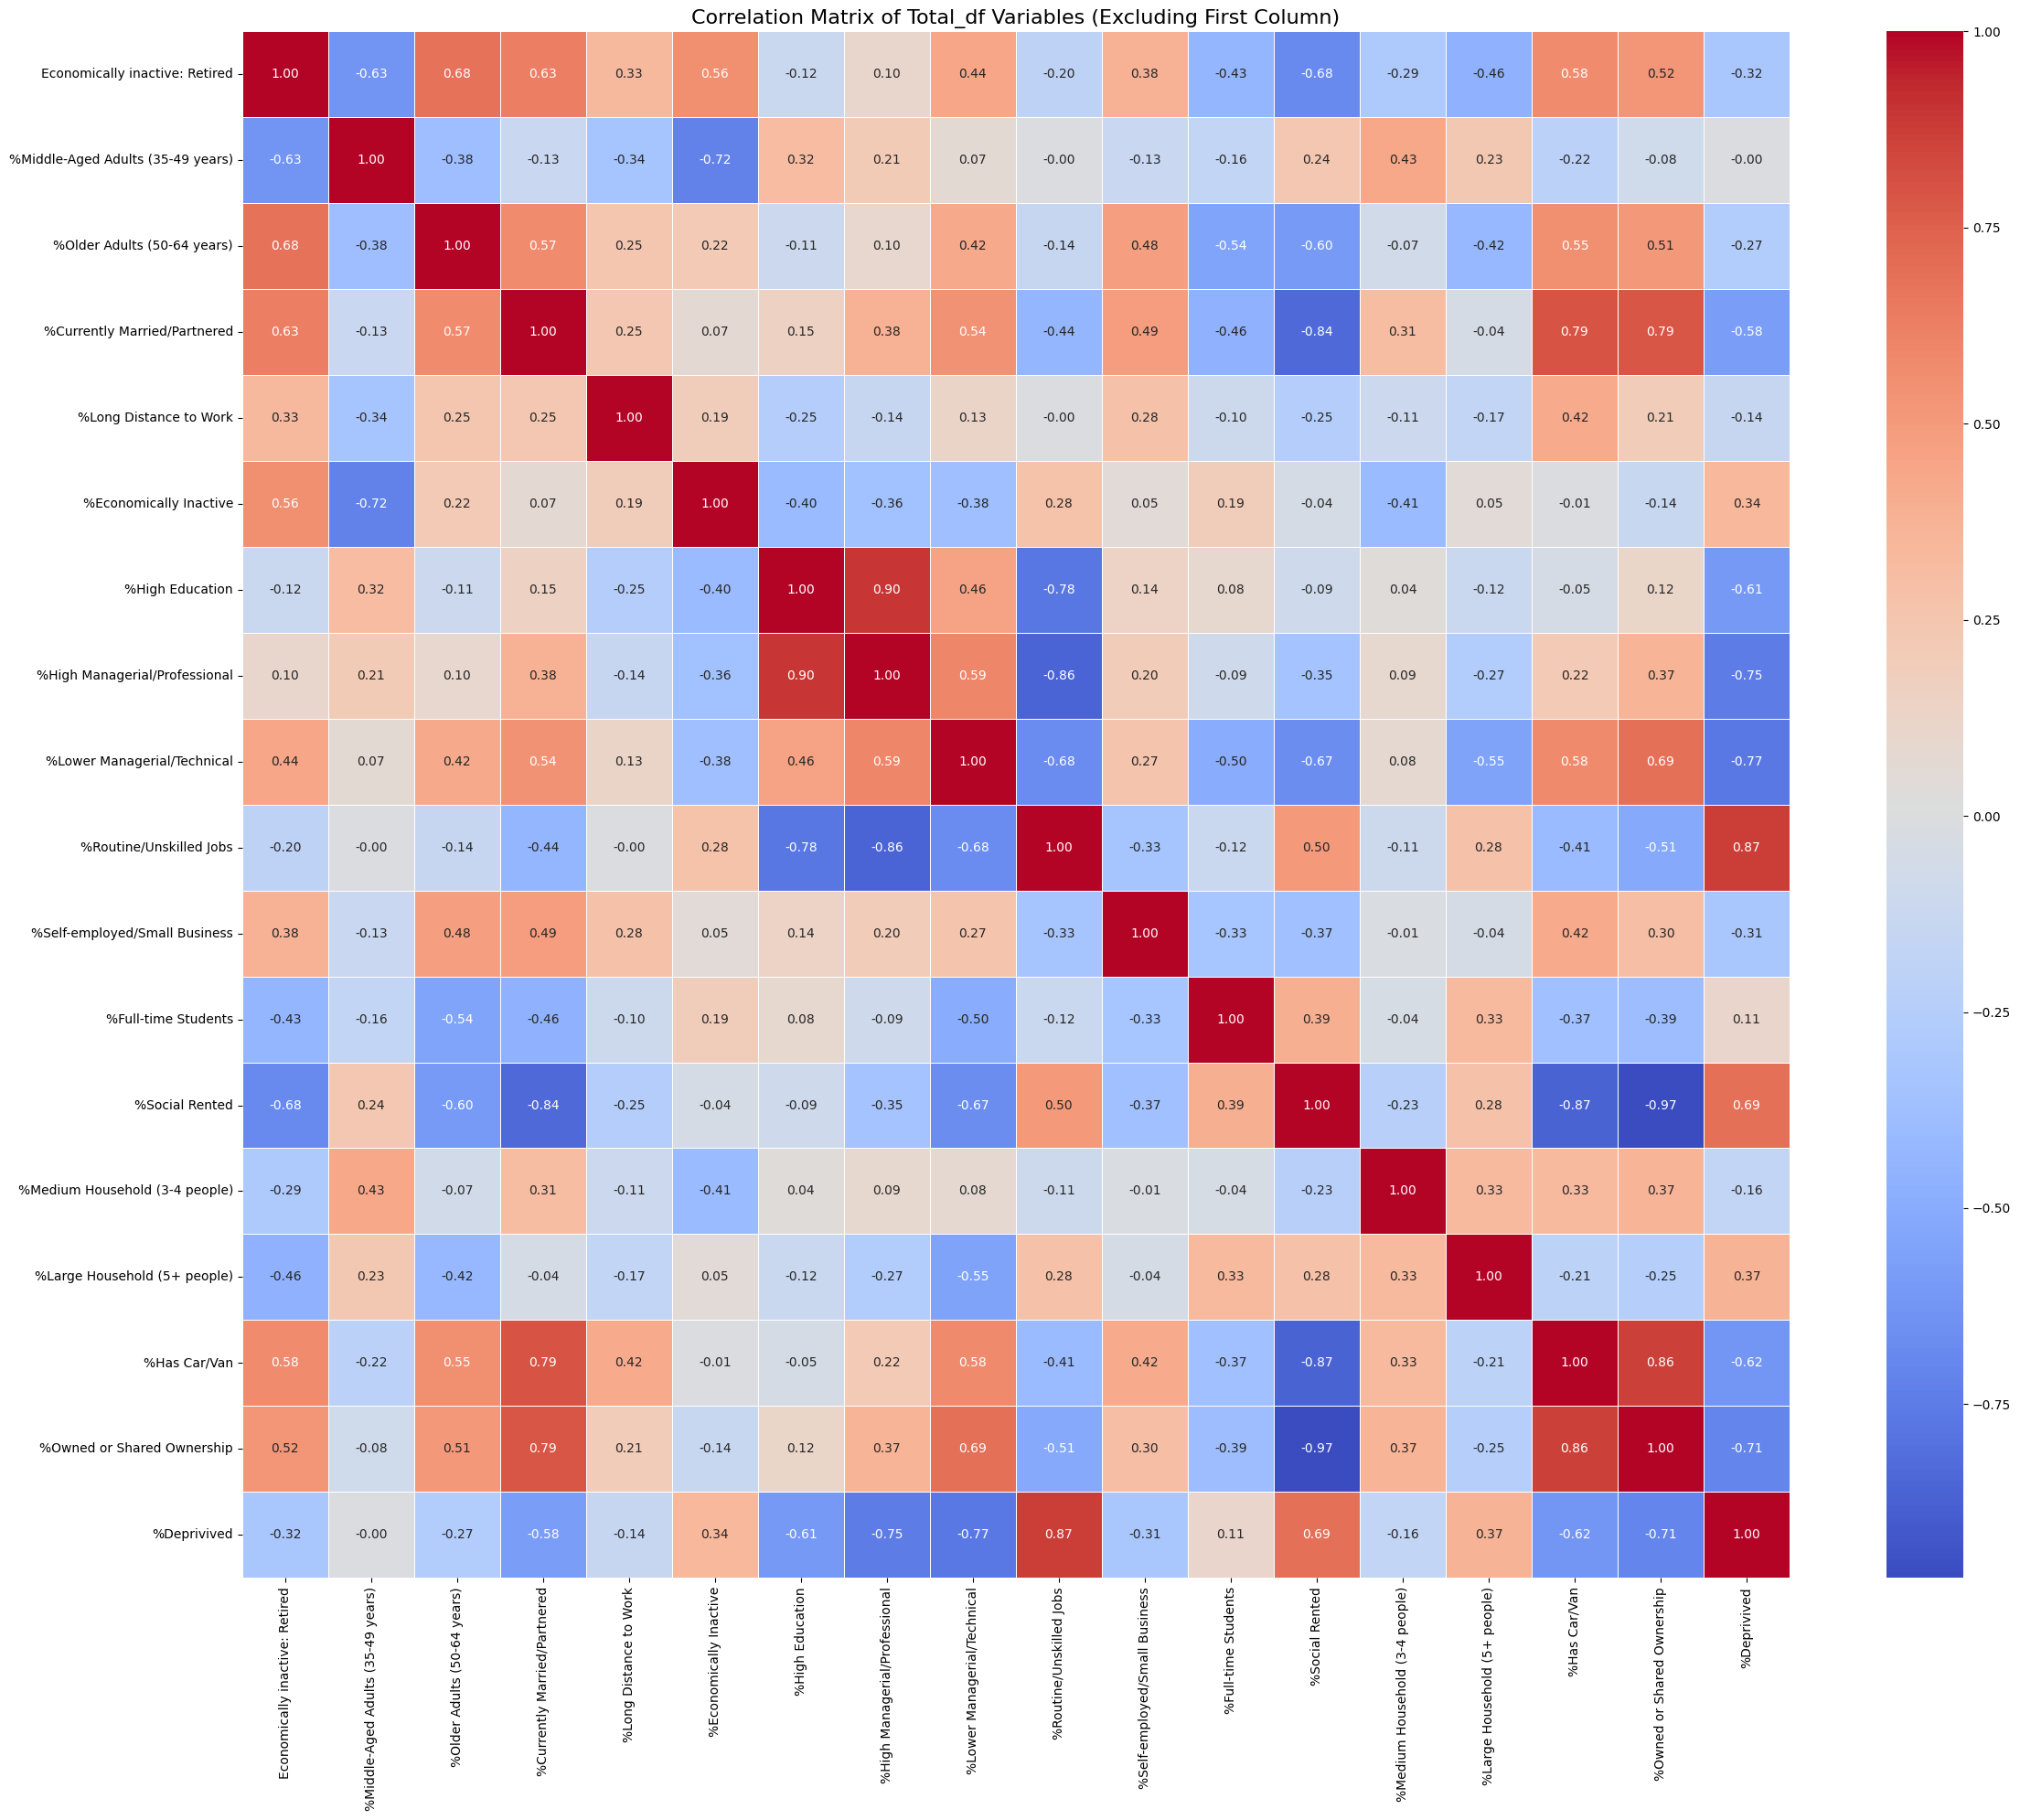

In [70]:
# Exclude the first column (assuming it's an identifier column like 'LSOA21CD' or similar)
df_without_first_column = df_for_clustering.iloc[:, 1:]

# Calculate the correlation matrix for the remaining columns
correlation_matrix = df_without_first_column.corr()

# Set up the matplotlib figure
plt.figure(figsize=(24, 20))

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

# Add title to the heatmap
plt.title("Correlation Matrix of Total_df Variables (Excluding First Column)", size=16)

# Show the plot
plt.tight_layout()
plt.show()


In [18]:
pip install statsmodels


   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.1/9.9 MB 3.6 MB/s eta 0:00:03
   - -------------------------------------- 0.4/9.9 MB 5.4 MB/s eta 0:00:02
   --- ------------------------------------ 0.8/9.9 MB 6.2 MB/s eta 0:00:02
   ----- ---------------------------------- 1.3/9.9 MB 8.1 MB/s eta 0:00:02
   ------ --------------------------------- 1.7/9.9 MB 7.7 MB/s eta 0:00:02
   -------- ------------------------------- 2.1/9.9 MB 8.5 MB/s eta 0:00:01
   --------- ------------------------------ 2.3/9.9 MB 7.7 MB/s eta 0:00:01
   --------- ------------------------------ 2.4/9.9 MB 7.4 MB/s eta 0:00:01
   ----------- ---------------------------- 2.7/9.9 MB 7.5 MB/s eta 0:00:01
   ------------ --------------------------- 3.1/9.9 MB 7.6 MB/s eta 0:00:01
   -------------- ------------------------- 3.6/9.9 MB 7.9 MB/s eta 0:00:01
   ---------------- ----------------------- 4.0/9.9 MB 8.3 MB/s eta 0:00:01
   ----------------


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: C:\Users\UTSM\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [69]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Assuming `total_df` is your DataFrame and the first column is excluded as it's an identifier
df_without_first_column = df_for_clustering.iloc[:, 1:]

# Calculate VIF for each variable
vif_data = pd.DataFrame()
vif_data['Variable'] = df_without_first_column.columns
vif_data['VIF'] = [variance_inflation_factor(df_without_first_column.values, i) for i in range(df_without_first_column.shape[1])]

# Display the VIF values
print(vif_data)


                             Variable         VIF
0      Economically inactive: Retired  119.534351
1   %Middle-Aged Adults (35-49 years)  136.346788
2         %Older Adults (50-64 years)   71.663752
3        %Currently Married/Partnered  153.129873
4              %Long Distance to Work    7.079920
5              %Economically Inactive  263.477665
6                     %High Education  133.695697
7       %High Managerial/Professional   93.513946
8         %Lower Managerial/Technical  337.883108
9             %Routine/Unskilled Jobs  246.121247
10      %Self-employed/Small Business   36.440707
11                %Full-time Students   27.128836
12                     %Social Rented  260.739434
13     %Medium Household (3-4 people)   58.746841
14       %Large Household (5+ people)   10.694803
15                       %Has Car/Van  203.496550
16         %Owned or Shared Ownership  566.724183
17                        %Deprivived   68.387325


In [67]:
variance_df = total_df.iloc[:, 1:].var()
sorted_variance_df = variance_df.sort_values(ascending=False)

# Display the sorted variances
print("Variables sorted by variance (highest to lowest):")
print(sorted_variance_df)

# Find the variable with the highest variance
highest_variance_variable = sorted_variance_df.idxmax()
highest_variance_value = sorted_variance_df.max()

# Display the variable with the highest variance
print(f"\nVariable with the highest variance: {highest_variance_variable}")
print(f"Highest variance value: {highest_variance_value}")


Variables sorted by variance (highest to lowest):
%Owned                                  819.648397
%Owned or Shared Ownership              816.076945
%Social Rented                          412.776361
%Multiple Cars/Vans                     263.979001
%Has Car/Van                            246.029132
%No Car/Van                             246.020928
%Private Rented                         163.532374
%High Education                         152.212105
%Routine/Unskilled Jobs                 151.785128
%Never Married                          136.267009
%Currently Married/Partnered            123.796191
%Short Distance to Work                 122.755082
%Fixed Workplace                        120.156177
%No Deprivation                         115.029151
%Small Household (1-2 people)            93.697617
Economically inactive: Retired           92.424093
%Low Education                           87.480978
%Elderly (65+ years)                     72.542005
%Deprivived                     

In [46]:
import pandas as pd

# Assuming total_df is your DataFrame

# Combine `%One Car/Van` and `%Multiple Cars/Vans` into `%Has Car/Van`
total_df['%Has Car/Van'] = total_df['%One Car/Van'] + total_df['%Multiple Cars/Vans']



# Combine `%Shared Ownership` with `%Owned` into `%Owned or Shared Ownership`
total_df['%Owned or Shared Ownership'] = total_df['%Owned'] + total_df['%Shared Ownership']

total_df['%Deprivived'] = total_df['%Medium Deprivation'] + total_df['%High Deprivation']

# After combining, drop the original columns
df_for_clustering = total_df.drop(columns=['%One Car/Van', '%Multiple Cars/Vans', 
                                           '%No Deprivation', '%Owned', 
                                           
                                           '%Shared Ownership'])

# Display the new DataFrame with combined variables
print("Updated DataFrame with combined categories:")
print(df_for_clustering.head())

# Optionally: Save the new DataFrame to a CSV file
# df_for_clustering.to_csv("df_for_clustering_combined.csv", index=False)


Updated DataFrame with combined categories:
                      LSOA21CD  Economically inactive: Retired  \
0  E01011954 : Hartlepool 001A                            18.0   
1  E01011969 : Hartlepool 001B                            38.0   
2  E01011970 : Hartlepool 001C                            33.6   
3  E01011971 : Hartlepool 001D                            16.3   
4  E01033465 : Hartlepool 001F                            14.5   

   %Children and Teenagers (0-19 years)  %Young Adults (20-34 years)  \
0                                  27.5                         20.5   
1                                  17.7                         13.2   
2                                  15.0                         16.3   
3                                  23.5                         17.9   
4                                  29.3                         16.1   

   %Middle-Aged Adults (35-49 years)  %Older Adults (50-64 years)  \
0                               17.3                     

In [68]:
# Assuming total_df is your DataFrame and you want to remove the specified columns
# List of columns to remove based on your request
columns_to_remove = [
    '%Zero Person Households', '%Lives Rent Free', '%High Deprivation', '%Shared Ownership', 
    '%Female', '%Poor Health', '%Fair Health', '%Low Deprivation', '%No Car/Van', 
    '%One Car/Van', '%Economically Active', '%Medium Deprivation', '%Private Rented', '%Owned', '%Children and Teenagers (0-19 years)', '%Young Adults (20-34 years)', 
    '%Previously Married','%Never Married', '%Small Household (1-2 people)',
    '%Short Distance to Work', '%Medium Distance to Work', '%Fixed Workplace', 
    '%Low Education', '%Medium Education', '%Elderly (65+ years)', '%No Deprivation', '%Good Health', '%Male', '%Multiple Cars/Vans', 
]

# Remove the specified columns
df_for_clustering = total_df.drop(columns=columns_to_remove, errors='ignore')

# Display the remaining columns after removal
print("Columns remaining after removal:")
print(df_for_clustering.columns)

# Optionally: Show the first few rows of the updated DataFrame
print(df_for_clustering.head())


Columns remaining after removal:
Index(['LSOA21CD', 'Economically inactive: Retired',
       '%Middle-Aged Adults (35-49 years)', '%Older Adults (50-64 years)',
       '%Currently Married/Partnered', '%Long Distance to Work',
       '%Economically Inactive', '%High Education',
       '%High Managerial/Professional', '%Lower Managerial/Technical',
       '%Routine/Unskilled Jobs', '%Self-employed/Small Business',
       '%Full-time Students', '%Social Rented',
       '%Medium Household (3-4 people)', '%Large Household (5+ people)',
       '%Has Car/Van', '%Owned or Shared Ownership', '%Deprivived'],
      dtype='object')
                      LSOA21CD  Economically inactive: Retired  \
0  E01011954 : Hartlepool 001A                            18.0   
1  E01011969 : Hartlepool 001B                            38.0   
2  E01011970 : Hartlepool 001C                            33.6   
3  E01011971 : Hartlepool 001D                            16.3   
4  E01033465 : Hartlepool 001F            

In [73]:
output_file_path = '../data/testingdata.csv'
df_for_clustering.to_csv(output_file_path, index=False)
